In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
from pathlib import Path

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp
from scipy.stats import randint, uniform

# 머신러닝 
import plotly.graph_objects as go
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error, mean_absolute_error, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, balanced_accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "lightgbm 패키지가 없습니다. `python3 -m pip install --user -r requirements.txt`를 실행한 뒤 노트북을 다시 실행하세요."
    ) from exc


from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('olist_project 루트를 찾을 수 없습니다. 노트북을 olist_project 또는 notebooks 폴더 안에서 실행하세요.')

PROJECT_ROOT = find_project_root()
DATA_RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
TABLE_DIR = OUTPUT_DIR / 'tables'
METADATA_DIR = OUTPUT_DIR / 'metadata'
OUTPUT_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
df = pd.read_csv(DATA_PROCESSED_DIR / 'merged_final_data.csv')


In [3]:
cols = df.columns
cols 


Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'category', 'seller_city', 'seller_state', 'order_purchase_dayofweek',
       'order_purchase_month', 'approved_days', 'dispatch_days',
       'delivery_days', 'expected_delivery_days', 'delay_days',
       'delay_days_int', 'is_delayed', 'delay_days_cat', 'main_category',
       'sub_category', 'distance_km', 'distance_cat', 'cross_state'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  109294 non-null  object 
 1   customer_id               109294 non-null  object 
 2   customer_unique_id        109294 non-null  object 
 3   customer_city             109294 non-null  object 
 4   customer_state            109294 non-null  object 
 5   order_item_id             109294 non-null  int64  
 6   seller_id                 109294 non-null  object 
 7   shipping_limit_date       109294 non-null  object 
 8   price                     109294 non-null  float64
 9   freight_value             109294 non-null  float64
 10  review_score              109294 non-null  int64  
 11  product_weight_g          109294 non-null  float64
 12  product_length_cm         109294 non-null  float64
 13  product_height_cm         109294 non-null  f

In [5]:
df.isna().sum()


order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_item_id                  0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
review_score                   0
product_weight_g               0
product_length_cm              0
product_height_cm              0
product_width_cm               0
category                    1545
seller_city                    0
seller_state                   0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
delay_days_int                 0
is_delayed                     0
delay_days_cat                 0
main_category                  0
sub_category                   0
distance_k

### 머신러닝 모델 생성시 절대 안쓸만한 컬럼 제거


In [6]:
cols_to_drop = ['customer_id','seller_id','category','delay_days_int']
df = df.drop(columns=cols_to_drop)
df['delay_days'] = df['delay_days'].astype(int) # delay_days 정수화


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  109294 non-null  object 
 1   customer_unique_id        109294 non-null  object 
 2   customer_city             109294 non-null  object 
 3   customer_state            109294 non-null  object 
 4   order_item_id             109294 non-null  int64  
 5   shipping_limit_date       109294 non-null  object 
 6   price                     109294 non-null  float64
 7   freight_value             109294 non-null  float64
 8   review_score              109294 non-null  int64  
 9   product_weight_g          109294 non-null  float64
 10  product_length_cm         109294 non-null  float64
 11  product_height_cm         109294 non-null  float64
 12  product_width_cm          109294 non-null  float64
 13  seller_city               109294 non-null  o

In [8]:
df.isna().sum()


order_id                    0
customer_unique_id          0
customer_city               0
customer_state              0
order_item_id               0
shipping_limit_date         0
price                       0
freight_value               0
review_score                0
product_weight_g            0
product_length_cm           0
product_height_cm           0
product_width_cm            0
seller_city                 0
seller_state                0
order_purchase_dayofweek    0
order_purchase_month        0
approved_days               0
dispatch_days               0
delivery_days               0
expected_delivery_days      0
delay_days                  0
is_delayed                  0
delay_days_cat              0
main_category               0
sub_category                0
distance_km                 0
distance_cat                0
cross_state                 0
dtype: int64

In [9]:
df.to_csv(DATA_PROCESSED_DIR / 'ml_data.csv', index=False)


In [10]:
df2 = df.copy()
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  109294 non-null  object 
 1   customer_unique_id        109294 non-null  object 
 2   customer_city             109294 non-null  object 
 3   customer_state            109294 non-null  object 
 4   order_item_id             109294 non-null  int64  
 5   shipping_limit_date       109294 non-null  object 
 6   price                     109294 non-null  float64
 7   freight_value             109294 non-null  float64
 8   review_score              109294 non-null  int64  
 9   product_weight_g          109294 non-null  float64
 10  product_length_cm         109294 non-null  float64
 11  product_height_cm         109294 non-null  float64
 12  product_width_cm          109294 non-null  float64
 13  seller_city               109294 non-null  o

In [11]:
# feature engineering

df2 = df.copy()

def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

# 배송 완료 후에만 알 수 있는 사후 물류 피처: Track A에서만 사용한다.
df2['delivery_speed'] = safe_divide(df2['distance_km'], df2['delivery_days'])
df2['day_per_km'] = safe_divide(df2['delivery_days'], df2['distance_km'])
df2['delivery_ratio'] = safe_divide(df2['delivery_days'], df2['expected_delivery_days'])

# 주문 시점에도 알 수 있는 가격/배송비 피처: Track A와 Track B 모두 사용 가능하다.
df2['freight_ratio'] = safe_divide(df2['freight_value'], df2['price'])
df2['total_price'] = df2['price'] + df2['freight_value']

# 배송 완료 후에만 확정되는 상호작용 피처: Track A에서만 사용한다.
df2['delivery_distance'] = df2['delivery_days'] * df2['distance_km']
df2['delivery_price'] = df2['delivery_days'] * df2['price']

df2 = df2.replace([np.inf, -np.inf], np.nan)


In [12]:
df2.isna().sum()


order_id                     0
customer_unique_id           0
customer_city                0
customer_state               0
order_item_id                0
shipping_limit_date          0
price                        0
freight_value                0
review_score                 0
product_weight_g             0
product_length_cm            0
product_height_cm            0
product_width_cm             0
seller_city                  0
seller_state                 0
order_purchase_dayofweek     0
order_purchase_month         0
approved_days                0
dispatch_days                0
delivery_days                0
expected_delivery_days       0
delay_days                   0
is_delayed                   0
delay_days_cat               0
main_category                0
sub_category                 0
distance_km                  0
distance_cat                 0
cross_state                  0
delivery_speed              18
day_per_km                  25
delivery_ratio               0
freight_

In [13]:
# 상파울루 고객 여부 (True/False를 1/0으로 변환)
df2['is_sp_customer'] = (df2['customer_state'] == 'SP').astype(int)

# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선)
df2['sp_route_type'] = 0

# 조건 1: 한 쪽이라도 SP인 경우 (부분적 인프라 혜택)
cond_partial = (df2['seller_state'] == 'SP') | (df2['customer_state'] == 'SP')
df2.loc[cond_partial, 'sp_route_type'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal, 'sp_route_type'] = 2


In [14]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109294 entries, 0 to 109293
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  109294 non-null  object 
 1   customer_unique_id        109294 non-null  object 
 2   customer_city             109294 non-null  object 
 3   customer_state            109294 non-null  object 
 4   order_item_id             109294 non-null  int64  
 5   shipping_limit_date       109294 non-null  object 
 6   price                     109294 non-null  float64
 7   freight_value             109294 non-null  float64
 8   review_score              109294 non-null  int64  
 9   product_weight_g          109294 non-null  float64
 10  product_length_cm         109294 non-null  float64
 11  product_height_cm         109294 non-null  float64
 12  product_width_cm          109294 non-null  float64
 13  seller_city               109294 non-null  o

In [15]:
### 상파울루인지 구분하는 컬럼
# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선)
df2['sp_route_type'] = 0

# 조건 1: 한 쪽이라도 SP인 경우 (부분적 인프라 혜택)
cond_partial = (df2['seller_state'] == 'SP') | (df2['customer_state'] == 'SP')
df2.loc[cond_partial, 'sp_route_type'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal, 'sp_route_type'] = 2



### 상파울루 고객 여부 (True/False를 1/0으로 변환)
df2['is_sp_customer'] = (df2['customer_state'] == 'SP').astype(int)

# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선 및 고객이 SP가 아닌 경우)
df2['sp_route_type_customer'] = 0

# 조건 1: 고객이 SP인 경우 (부분적 인프라 혜택)
cond_partial = (df2['customer_state'] == 'SP')
df2.loc[cond_partial, 'sp_route_type_customer'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal, 'sp_route_type_customer'] = 2

# 결과 확인
print(df2['sp_route_type_customer'].value_counts().sort_index())



### 상파울루 셀러 여부 (True/False를 1/0으로 변환)
df2['is_sp_seller'] = (df2['seller_state'] == 'SP').astype(int)

# 기본값을 0으로 설정 (둘 다 SP가 아닌 경우: 일반/장거리 노선 및 셀러가 SP가 아닌 경우)
df2['sp_route_type_seller'] = 0

# 조건 1: 셀러가 SP인 경우 (부분적 인프라 혜택)
cond_partial_seller = (df2['seller_state'] == 'SP')
df2.loc[cond_partial_seller, 'sp_route_type_seller'] = 1

# 조건 2: 둘 다 SP인 경우 (최적화된 인프라, 라스트마일 최적화)
cond_internal_seller = (df2['seller_state'] == 'SP') & (df2['customer_state'] == 'SP')
df2.loc[cond_internal_seller, 'sp_route_type_seller'] = 2

# 결과 확인
print(df2['sp_route_type_seller'].value_counts().sort_index())


sp_route_type_customer
0    63171
1    10959
2    35164
Name: count, dtype: int64


sp_route_type_seller
0    31348
1    42782
2    35164
Name: count, dtype: int64


# 분류모델


## 모델 사용 시점 정의: Track A (사후 원인분석 모델)

아래에서 구축하는 분류 모델은 **주문이 배송 완료된 이후 시점에만 사용 가능한 모델**입니다.

- 입력 feature 중 `delay_days`, `is_delayed`, `delay_days_cat`, `delivery_days`와 이로부터 파생된 `delivery_speed`, `delivery_ratio`, `delivery_distance`, `delivery_price`, `day_per_km`는 배송이 끝나야만 확정되는 값입니다.
- 따라서 이 모델은 "주문 시점에 미래 리뷰를 예측"하는 용도가 아니라, **배송 완료 후 어떤 주문이 부정 리뷰로 이어질 위험이 높은지 진단하여 CS 우선 대응·환불/보상 판단에 활용하는 사후 원인분석(Track A) 모델**입니다.
- 주문 시점(배송 전)에 리스크를 예측해 선제 대응하려면, 배송 결과 관련 feature를 모두 제외한 별도의 Track B(사전 예측) 모델이 필요합니다.


### 긍정/부정 그룹화
#### CS 리스크 기준: 1-3점은 부정, 4-5점은 긍정


In [16]:
# 분류모델 시 그룹화 함수 정의
def group_score(score):
    if score >= 4: return 1   # 긍정
    else: return 0            # 부정

# order_id는 feature로 쓰지 않지만, train/valid/test 분리 시 같은 주문이 여러 split에 걸치지 않도록
# groups로 별도 보관합니다 (order_item_id로 인해 한 주문이 여러 행으로 늘어나 있음)
groups = df2['order_id']

X = df2.drop(columns=['review_score','order_id','customer_unique_id','customer_city','customer_state',
                      'shipping_limit_date','seller_city','seller_state'])
y = df2['review_score'].apply(group_score)


In [17]:
# 1. 원본 데이터 상태에서 분리 (원핫 인코딩 수행 전)
# 같은 order_id를 공유하는 행(한 주문의 여러 아이템)이 train/valid/test에 걸쳐 나뉘면
# 사실상 동일한 정보가 여러 split에 누수되므로, order_id 단위로 그룹을 묶어 분리합니다.
# GroupShuffleSplit은 그룹 비중첩을 보장하지만 stratify는 지원하지 않으므로,
# 분리 후 클래스 비율은 별도로 확인합니다.
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_valid_idx, test_idx = next(gss1.split(X, y, groups=groups))
X_train_valid, X_test = X.iloc[train_valid_idx], X.iloc[test_idx]
y_train_valid, y_test = y.iloc[train_valid_idx], y.iloc[test_idx]
groups_train_valid = groups.iloc[train_valid_idx]
groups_test = groups.iloc[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(gss2.split(X_train_valid, y_train_valid, groups=groups_train_valid))
X_train, X_valid = X_train_valid.iloc[train_idx], X_train_valid.iloc[valid_idx]
y_train, y_valid = y_train_valid.iloc[train_idx], y_train_valid.iloc[valid_idx]
groups_train = groups_train_valid.iloc[train_idx]
groups_valid = groups_train_valid.iloc[valid_idx]

display(pd.DataFrame({
    'split': ['train', 'valid', 'test'],
    'rows': [len(X_train), len(X_valid), len(X_test)],
    'orders': [groups_train.nunique(), groups_valid.nunique(), groups_test.nunique()],
    'positive_rate': [y_train.mean(), y_valid.mean(), y_test.mean()]
}))

# 2. 수치형/범주형 컬럼 분리
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

# 3. 전처리 파이프라인 정의
numeric_transformer = SimpleImputer(strategy='median') # 수치형은 중앙값으로 결측치 대체
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # 범주형은 최빈값으로 대체
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True)) # 새로운 범주 등장 시 무시
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# 하이퍼파라미터 탐색에서도 같은 주문이 서로 다른 fold로 나뉘지 않도록 그룹 기반 CV를 사용한다.
group_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)


,split,rows,orders,positive_rate
0,train,69914,61301,0.769059
1,valid,17568,15326,0.766507
2,test,21812,19157,0.767467


### 1번째 분류모델: LightGBMClassifier


In [18]:
# 4. 최종 모델 파이프라인 구축
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=800,
        learning_rate=0.014883605700319194,
        num_leaves=47,
        max_depth=7,
        colsample_bytree=0.6218455076693483,
        min_child_samples=47,
        class_weight='balanced',
        random_state=42, 
        verbose=-1
    ))
])

# 5. 파이프라인 학습 (내부적으로 X_train만 전처리 규칙을 학습)
lgbm_pipeline.fit(X_train, y_train)

# 예측 시에는 파이프라인이 자동으로 X_valid를 변환 후 예측함
valid_proba_lgbm = lgbm_pipeline.predict_proba(X_valid)[:, 1]


In [19]:
# 아래 하이퍼파라미터 탐색 / 모델 비교 코드는 1회 실행하여 이미 최적값을 확정했습니다.
# 재검증하려면 True로 바꾼 뒤 재실행하세요 (RandomizedSearchCV + GridSearchCV 3종 포함, 수 분~수십 분 소요).
# 탐색 CV는 StratifiedGroupKFold를 사용해 order_id 단위 누수를 방지합니다.
# 실행 결과는 outputs/tables/model_comparison_results.csv 에 근거 자료로 저장되어 있습니다.
RUN_MODEL_COMPARISON = False


In [20]:
# 마지막 LightGBM 하이퍼파라미터 튜닝
if RUN_MODEL_COMPARISON:
    # LightGBM 탐색 공간
    lgbm_expanded_param = {
        'classifier__n_estimators': [300, 500, 800],          # 트리 개수를 극단적으로 높임
        'classifier__learning_rate': uniform(0.01, 0.05),   # 트리 개수가 많으므로 학습률은 낮춤
        'classifier__num_leaves': randint(20, 50),        # 복잡도 조절의 핵심 (기본값 31)
        'classifier__max_depth': [4, 5, 6, 7, 8],          # 트리 깊이 제한
        'classifier__min_child_samples': randint(20, 50), # 과적합 방지를 위한 최소 샘플 수
        'classifier__colsample_bytree': uniform(0.5, 0.4)  # 0.5~0.9 사이 피처 샘플링 비율
    }

    lgbm_random_search = RandomizedSearchCV(
        estimator=lgbm_pipeline, # 파이프라인 내 LightGBM (verbose=-1 유지)
        param_distributions=lgbm_expanded_param,
        n_iter=20,           # 20번만 탐색
        cv=group_cv,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    lgbm_random_search.fit(X_train, y_train, groups=groups_train)

    # 결과 확인
    print("Best Parameters:", lgbm_random_search.best_params_)
    print("Best Macro F1 Score:", lgbm_random_search.best_score_)
    # (order_id 기준 StratifiedGroupKFold 재탐색 완료: outputs/tables/model_comparison_results.csv 반영)


In [21]:
# threshold 평가 함수
def evaluate_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    neg_recall = recall_score(y_true, pred, pos_label=0)
    macro_f1 = f1_score(y_true, pred, average="macro")
    weighted_f1 = f1_score(y_true, pred, average="weighted")
    acc = accuracy_score(y_true, pred)
    bal_acc = balanced_accuracy_score(y_true, pred)


    return {
        "threshold": threshold,
        "neg_recall": neg_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": acc,
        "balanced_acc": bal_acc,
        "tn": cm[0,0],
        "fp": cm[0,1],
        "fn": cm[1,0],
        "tp": cm[1,1],
    }


# 0.01씩 threshold 바꿔가며 비교
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for th in thresholds:
    row = evaluate_threshold(y_valid, valid_proba_lgbm, th)
    results.append(row)

threshold_df = pd.DataFrame(results)


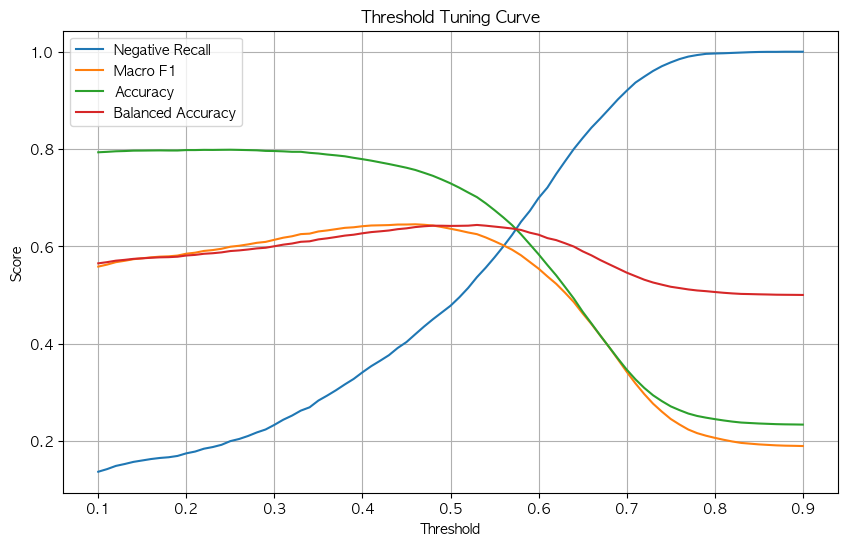

In [22]:
# 시각화

plt.figure(figsize=(10, 6))

plt.plot(threshold_df["threshold"], threshold_df["neg_recall"], label="Negative Recall")
plt.plot(threshold_df["threshold"], threshold_df["macro_f1"], label="Macro F1")
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["balanced_acc"], label="Balanced Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Curve")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# neg_recall과 balanced_acc 차이
# 이 기준은 class 0(부정) recall과 class 1(긍정) recall을 비슷하게 맞추는 보수적 운영 기준이다.
# 실제 배포 단계에서는 CS 처리 비용과 부정 리뷰 미탐 비용을 반영해 threshold를 다시 정해야 한다.
threshold_df["gap"] = (threshold_df["neg_recall"] - threshold_df["balanced_acc"]).abs()

best_row = threshold_df.loc[threshold_df["gap"].idxmin()]
best_threshold = best_row["threshold"]

print("선택된 threshold:", best_threshold)
print(best_row[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])


선택된 threshold: 0.5699999999999997
threshold       0.570000
neg_recall      0.623842
balanced_acc    0.636702
macro_f1        0.593070
accuracy        0.643556
Name: 47, dtype: float64


In [24]:
# 평가
valid_pred = (valid_proba_lgbm >= best_threshold).astype(int)


print("VALID ACC:", accuracy_score(y_valid, valid_pred))
print("VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred))
print("VALID Negative Recall:", recall_score(y_valid, valid_pred, pos_label=0))
print("VALID F1(macro):", f1_score(y_valid, valid_pred, average='macro'))
print("VALID F1(weighted):", f1_score(y_valid, valid_pred, average='weighted'))
print(classification_report(y_valid, valid_pred, zero_division=0))
print("VALID confusion matrix")
print(confusion_matrix(y_valid, valid_pred))


VALID ACC: 0.643556466302368
VALID Balanced ACC: 0.6367019438884416
VALID Negative Recall: 0.6238420282788883
VALID F1(macro): 0.5930699072675304
VALID F1(weighted): 0.6694687661560597
              precision    recall  f1-score   support

           0       0.35      0.62      0.45      4102
           1       0.85      0.65      0.74     13466

    accuracy                           0.64     17568
   macro avg       0.60      0.64      0.59     17568
weighted avg       0.73      0.64      0.67     17568

VALID confusion matrix
[[2559 1543]
 [4719 8747]]


In [25]:
actual_feature_names = preprocessor.get_feature_names_out() 

X_train_transformed = preprocessor.fit_transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)

# 최종 모델 구축
lgbm_model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.014883605700319194,
        num_leaves=47,
        max_depth=7,
        colsample_bytree=0.6218455076693483,
        min_child_samples=47,
        class_weight='balanced',
        random_state=42, 
        verbose=-1
)

import matplotlib.pyplot as plt
from lightgbm import early_stopping, log_evaluation
# 파이프라인 학습 (내부적으로 X_train만 전처리 규칙을 학습)
print("LGBM 분류 모델 학습을 시작합니다...")
lgbm_model.fit(
    X_train_transformed, 
    y_train,
    # [수정] Train과 Valid를 모두 넣어 비교할 수 있게 만듭니다.
    eval_set=[(X_train_transformed, y_train), (X_valid_transformed, y_valid)], 
    eval_names=['Train', 'Validation'],
    # [수정] 50번 동안 점수 개선이 없으면 조기 종료, 50번마다 로그 출력
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(50)] 
)

# 예측 시에는 파이프라인이 자동으로 X_valid를 변환 후 예측함
valid_proba_lgbm = lgbm_model.predict_proba(X_valid_transformed)[:, 1]


LGBM 분류 모델 학습을 시작합니다...


Training until validation scores don't improve for 50 rounds


[50]	Train's binary_logloss: 0.633727	Validation's binary_logloss: 0.636645


[100]	Train's binary_logloss: 0.610655	Validation's binary_logloss: 0.615165


[150]	Train's binary_logloss: 0.599286	Validation's binary_logloss: 0.606391


...

[600]	Train's binary_logloss: 0.558412	Validation's binary_logloss: 0.59296


[650]	Train's binary_logloss: 0.554426	Validation's binary_logloss: 0.592073


[700]	Train's binary_logloss: 0.550919	Validation's binary_logloss: 0.591288


[750]	Train's binary_logloss: 0.547493	Validation's binary_logloss: 0.590582


[800]	Train's binary_logloss: 0.544267	Validation's binary_logloss: 0.589949
Did not meet early stopping. Best iteration is:
[800]	Train's binary_logloss: 0.544267	Validation's binary_logloss: 0.589949


학습 자동 종료 완료! (최적의 트리 개수: 800)


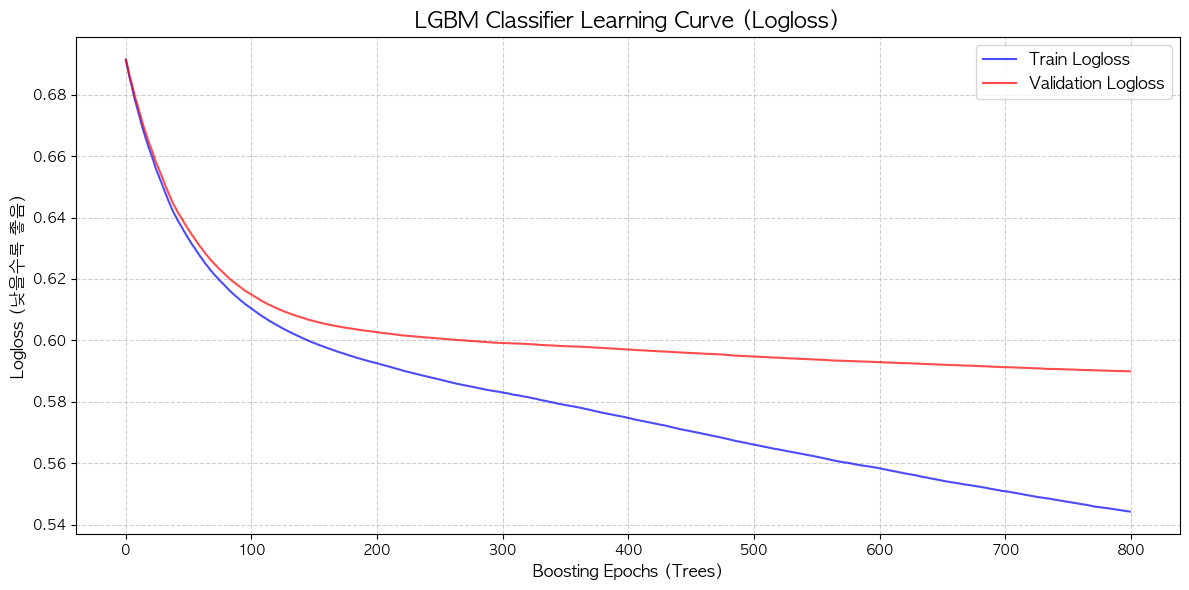

In [26]:
print(f"학습 자동 종료 완료! (최적의 트리 개수: {lgbm_model.best_iteration_})")

# 3. 러닝 커브 (Learning Curve) 시각화
plt.figure(figsize=(12, 6))

# LightGBM은 evals_result_ 에 학습 기록을 저장
results = lgbm_model.evals_result_
metric_name = list(results['Train'].keys())[0] 
epochs = len(results['Train'][metric_name])
x_axis = range(0, epochs)

# Train과 Valid의 Loss가 같이 떨어지다가, Valid가 다시 올라가는 시점이 과적합(Overfitting) 시작점입니다.
plt.plot(x_axis, results['Train'][metric_name], label='Train Logloss', color='blue', alpha=0.7)
plt.plot(x_axis, results['Validation'][metric_name], label='Validation Logloss', color='red', alpha=0.7)

plt.title("LGBM Classifier Learning Curve (Logloss)", fontsize=16)
plt.xlabel("Boosting Epochs (Trees)", fontsize=12)
plt.ylabel("Logloss (낮을수록 좋음)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [27]:
# 피처 중요도 확인

imp = pd.Series(
    lgbm_model.feature_importances_,
    index=actual_feature_names
).sort_values(ascending=False)

print(imp.head(50))


num__delivery_ratio                             2081
num__freight_value                              2033
num__freight_ratio                              1919
num__product_weight_g                           1860
num__delivery_price                             1775
num__distance_km                                1757
num__delay_days                                 1687
num__product_height_cm                          1634
num__product_length_cm                          1620
num__delivery_distance                          1555
num__price                                      1549
num__total_price                                1495
num__expected_delivery_days                     1493
num__delivery_speed                             1378
num__order_purchase_month                       1276
num__day_per_km                                 1266
num__product_width_cm                           1247
num__delivery_days                              1161
num__dispatch_days                            

### 2번째 분류모델: RandomForestClassifier


In [28]:
if RUN_MODEL_COMPARISON:
    from sklearn.base import clone

    # 1. 랜덤 포레스트 파이프라인 정의 (전처리기는 LGBM과 별개 객체로 clone하여 전역 preprocessor를 건드리지 않음)
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=15,
            min_samples_split=10,
            random_state=42,
            n_estimators=200,
            n_jobs=-1  # 병렬 처리를 위해 가용 CPU 코어 모두 사용
        ))
    ])

    # 2. GridSearchCV를 위한 하이퍼파라미터 탐색 공간(Grid) 정의
    rf_param_grid = {
        'classifier__n_estimators': [100, 200, 300],  # 숲을 구성할 트리의 개수
        'classifier__max_depth': [5, 10, 15],         # 트리의 최대 깊이
        'classifier__min_samples_split': [2, 5, 10]   # 노드를 분할하기 위한 최소 데이터 수
    }

    # 3. GridSearchCV 객체 생성
    rf_grid_search = GridSearchCV(
        estimator=rf_pipeline,
        param_grid=rf_param_grid,
        cv=group_cv,          # order_id 단위 누수를 막는 그룹 기반 3-Fold CV
        scoring='f1_macro',   # 불균형 데이터이므로 Macro F1 타겟
        n_jobs=-1,            # 그리드 서치 자체의 병렬 처리
        verbose=1
    )

    # 4. 파이프라인 학습 및 최적 파라미터 탐색 (X_train은 인코딩되지 않은 원본 분할 상태)
    rf_grid_search.fit(X_train, y_train, groups=groups_train)

    print("Best Random Forest Parameters:", rf_grid_search.best_params_)
    print("Best Macro F1 Score:", rf_grid_search.best_score_)
    # (order_id 기준 StratifiedGroupKFold 재탐색 완료: outputs/tables/model_comparison_results.csv 반영)

    # 5. 최적 파이프라인으로 Valid 세트 예측
    best_rf_pipeline = rf_grid_search.best_estimator_
    valid_proba_rf = best_rf_pipeline.predict_proba(X_valid)[:, 1]

    # 6. 0.01씩 threshold 바꿔가며 비교 (LGBM과 동일한 evaluate_threshold 함수 재사용)
    results_rf = []
    for th in thresholds:
        row = evaluate_threshold(y_valid, valid_proba_rf, th)
        results_rf.append(row)
    threshold_df_rf = pd.DataFrame(results_rf)

    # 7. 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(threshold_df_rf["threshold"], threshold_df_rf["neg_recall"], label="Negative Recall")
    plt.plot(threshold_df_rf["threshold"], threshold_df_rf["macro_f1"], label="Macro F1")
    plt.plot(threshold_df_rf["threshold"], threshold_df_rf["accuracy"], label="Accuracy")
    plt.plot(threshold_df_rf["threshold"], threshold_df_rf["balanced_acc"], label="Balanced Accuracy")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Tuning Curve (Random Forest)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 8. neg_recall과 balanced_acc 차이(=recall_0≈recall_1 지점)가 최소인 threshold 선택
    threshold_df_rf["gap"] = (threshold_df_rf["neg_recall"] - threshold_df_rf["balanced_acc"]).abs()
    best_row_rf = threshold_df_rf.loc[threshold_df_rf["gap"].idxmin()]
    best_threshold_rf = best_row_rf["threshold"]

    print("RF 선택된 threshold:", best_threshold_rf)
    print(best_row_rf[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])
    # 선택된 threshold: 0.5699999999999997
    # threshold       0.570000
    # neg_recall      0.613603
    # balanced_acc    0.631397
    # macro_f1        0.589318
    # accuracy        0.640881

    # 9. 평가
    valid_pred_rf = (valid_proba_rf >= best_threshold_rf).astype(int)

    print("RF VALID ACC:", accuracy_score(y_valid, valid_pred_rf))
    print("RF VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred_rf))
    print("RF VALID Negative Recall:", recall_score(y_valid, valid_pred_rf, pos_label=0))
    print("RF VALID F1(macro):", f1_score(y_valid, valid_pred_rf, average='macro'))
    print("RF VALID F1(weighted):", f1_score(y_valid, valid_pred_rf, average='weighted'))
    print(classification_report(y_valid, valid_pred_rf, zero_division=0))
    print("RF VALID confusion matrix")
    print(confusion_matrix(y_valid, valid_pred_rf))


### 3번째 분류모델: XGBoost Classifier


In [29]:
if RUN_MODEL_COMPARISON:
    from sklearn.base import clone

    # 1. XGBoost 파이프라인 정의 (전처리기는 별개 객체로 clone)
    xgb_pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('classifier', XGBClassifier(
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss',
            verbose=-1
        ))
    ])

    # 2. 탐색할 하이퍼파라미터 그리드 정의
    xgb_param_grid = {
        'classifier__n_estimators': [200, 300, 500, 800, 1000],
        'classifier__learning_rate': [0.01, 0.05],
        'classifier__max_depth': [5, 7],
        'classifier__min_child_weight': [1, 3, 5], # 가지치기의 기준이 되는 가중치 합
        'classifier__gamma': [0, 0.1, 0.5],        # 값이 클수록 보수적인 알고리즘(가지치기 강화)
    }

    # 3. GridSearchCV 객체 생성
    xgb_grid_search = GridSearchCV(
        estimator=xgb_pipeline,
        param_grid=xgb_param_grid,
        cv=group_cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    # 4. 파이프라인 학습 및 최적 탐색 (X_train은 원본 형태여야 함)
    xgb_grid_search.fit(X_train, y_train, groups=groups_train)

    print("Best XGBoost Parameters:", xgb_grid_search.best_params_)
    print("Best Macro F1 Score:", xgb_grid_search.best_score_)
    # (order_id 기준 StratifiedGroupKFold 재탐색 완료: outputs/tables/model_comparison_results.csv 반영)

    # 5. 최적 파라미터 + early stopping으로 최종 XGB 모델 학습
    # (Pipeline은 fit 시 eval_set 변환을 지원하지 않아 전처리기를 직접 fit_transform)
    preprocessor_xgb = clone(preprocessor)
    X_train_processed = preprocessor_xgb.fit_transform(X_train)
    X_valid_processed = preprocessor_xgb.transform(X_valid)

    final_xgb_model = XGBClassifier(
        max_depth=7,
        learning_rate=0.05,
        min_child_weight=3,
        random_state=42,
        gamma=0,
        n_estimators=1000,
        n_jobs=-1,
        eval_metric='logloss',
        early_stopping_rounds=30 # 30번 연속 Valid 점수 개선 없으면 자동 종료
    )

    final_xgb_model.fit(
        X_train_processed,
        y_train,
        eval_set=[(X_valid_processed, y_valid)],
        verbose=0
    )

    valid_proba_xgbm = final_xgb_model.predict_proba(X_valid_processed)[:, 1]
    print(f"최적의 나무 개수(Best Iteration): {final_xgb_model.best_iteration}")
    # 최적의 나무 개수(Best Iteration): 67

    # 6. 0.01씩 threshold 바꿔가며 비교
    results_xgb = []
    for th in thresholds:
        row = evaluate_threshold(y_valid, valid_proba_xgbm, th)
        results_xgb.append(row)
    threshold_df_xgb = pd.DataFrame(results_xgb)

    # 7. 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(threshold_df_xgb["threshold"], threshold_df_xgb["neg_recall"], label="Negative Recall")
    plt.plot(threshold_df_xgb["threshold"], threshold_df_xgb["macro_f1"], label="Macro F1")
    plt.plot(threshold_df_xgb["threshold"], threshold_df_xgb["accuracy"], label="Accuracy")
    plt.plot(threshold_df_xgb["threshold"], threshold_df_xgb["balanced_acc"], label="Balanced Accuracy")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Tuning Curve (XGBoost)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 8. neg_recall과 balanced_acc 차이가 최소인 threshold 선택
    threshold_df_xgb["gap"] = (threshold_df_xgb["neg_recall"] - threshold_df_xgb["balanced_acc"]).abs()
    best_row_xgb = threshold_df_xgb.loc[threshold_df_xgb["gap"].idxmin()]
    best_threshold_xgb = best_row_xgb["threshold"]

    print("XGB 선택된 threshold:", best_threshold_xgb)
    print(best_row_xgb[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])
    # 선택된 threshold: 0.8099999999999996
    # threshold       0.810000
    # neg_recall      0.615066
    # balanced_acc    0.633948
    # macro_f1        0.592086
    # accuracy        0.644012

    # 9. 평가
    valid_pred_xgb = (valid_proba_xgbm >= best_threshold_xgb).astype(int)

    print("XGB VALID ACC:", accuracy_score(y_valid, valid_pred_xgb))
    print("XGB VALID Balanced ACC:", balanced_accuracy_score(y_valid, valid_pred_xgb))
    print("XGB VALID Negative Recall:", recall_score(y_valid, valid_pred_xgb, pos_label=0))
    print("XGB VALID F1(macro):", f1_score(y_valid, valid_pred_xgb, average='macro'))
    print("XGB VALID F1(weighted):", f1_score(y_valid, valid_pred_xgb, average='weighted'))
    print(classification_report(y_valid, valid_pred_xgb, zero_division=0))
    print("XGB VALID confusion matrix")
    print(confusion_matrix(y_valid, valid_pred_xgb))


In [30]:
# RUN_MODEL_COMPARISON=False 상태에서도 3개 모델 비교 근거를 확인할 수 있도록,
# StratifiedGroupKFold(order_id groups) 기준으로 재탐색해 저장한 CSV를 불러와 표로 보여줍니다.
model_comparison = pd.read_csv(TABLE_DIR / 'model_comparison_results.csv')
model_comparison


,model,best_params,cv_scoring,cv_best_macro_f1,best_threshold,neg_recall,balanced_acc,macro_f1,accuracy,cv_note
0,LightGBM,{'classifier__colsample_bytree': 0.62184550766...,f1_macro,0.646062,0.57,0.624573,0.636214,0.592255,0.642418,refreshed with StratifiedGroupKFold(order_id g...
1,RandomForest,"{'classifier__max_depth': 10, 'classifier__min...",f1_macro,0.648390,0.57,0.623354,0.632634,0.588135,0.637580,refreshed with StratifiedGroupKFold(order_id g...
2,XGBoost,"{'classifier__gamma': 0, 'classifier__learning...",f1_macro,0.616267,0.82,0.613847,0.619748,0.574826,0.622894,refreshed with StratifiedGroupKFold(order_id g...


### 분류모델(Track A - 사후 원인분석) : LightGBM Classifier로 결정

`StratifiedGroupKFold`로 order_id 단위 누수를 막고 3개 모델을 재탐색한 결과, 최종 Track A 모델은 LightGBM으로 결정하였다.

- LightGBM은 validation 기준 부정 recall이 가장 높았다.
- RandomForest는 CV macro F1은 근소하게 높았지만, validation의 부정 recall과 macro F1이 LightGBM보다 낮았다.
- XGBoost는 전체 grid search를 수행했지만, 부정 recall과 macro F1 모두 LightGBM보다 낮았다.

따라서 이 프로젝트의 목적이 “부정 리뷰 위험 주문을 놓치지 않는 것”에 가깝다는 점을 고려해 LightGBM을 최종 Track A 모델로 사용한다.


TEST SET EVALUATION RESULTS (Pipeline Model)
TEST ACC: 0.6522
TEST Balanced ACC: 0.6507
TEST Negative Recall (Class 0): 0.6479
TEST F1 (macro): 0.6034
TEST F1 (weighted): 0.6778

[Classification Report]
              precision    recall  f1-score   support

           0       0.36      0.65      0.46      5072
           1       0.86      0.65      0.74     16740

    accuracy                           0.65     21812
   macro avg       0.61      0.65      0.60     21812
weighted avg       0.74      0.65      0.68     21812

[Confusion Matrix]
[[ 3286  1786]
 [ 5800 10940]]


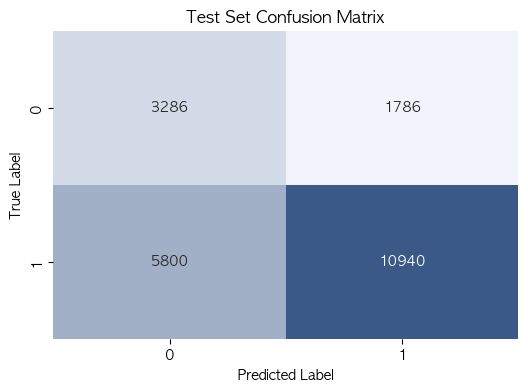

In [31]:
# 1. Test set 예측 (파이프라인을 사용하면 전처리와 예측이 튜닝 때와 완벽히 동일하게 진행됩니다)
test_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

# 2. Validation set에서 찾은 최적의 임계값(best_threshold) 적용
test_pred = (test_proba_lgbm >= best_threshold).astype(int)

# 3. Test set 결과 평가 및 출력
print("============================================================")
print("TEST SET EVALUATION RESULTS (Pipeline Model)")
print("============================================================")
print(f"TEST ACC: {accuracy_score(y_test, test_pred):.4f}")
print(f"TEST Balanced ACC: {balanced_accuracy_score(y_test, test_pred):.4f}")
print(f"TEST Negative Recall (Class 0): {recall_score(y_test, test_pred, pos_label=0):.4f}")
print(f"TEST F1 (macro): {f1_score(y_test, test_pred, average='macro'):.4f}")
print(f"TEST F1 (weighted): {f1_score(y_test, test_pred, average='weighted'):.4f}")

print("\n[Classification Report]")
print(classification_report(y_test, test_pred, zero_division=0))

print("[Confusion Matrix]")
print(confusion_matrix(y_test, test_pred))

# 시각화 - Confusion Matrix
blue_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue", ["#F0F4FA", "#3B5987"])

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, test_pred), annot=True, fmt='d', cmap=blue_cmap, cbar=False)
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# Track B: 사전 예측 모델 (배송 전 리스크 예측)

Track A는 배송이 끝난 뒤에만 쓸 수 있는 모델이었습니다. Track B는 **주문이 확정된 시점(배송 시작 전)**에 이미 알 수 있는 정보만으로 부정 리뷰 위험을 예측합니다. 실무에서 "고위험 주문 우선 발송, 선제 안내" 같은 사전 개입에 쓸 수 있는 모델은 이쪽입니다.

## Feature 재정의: 주문 시점에 아는 값만 사용

- 포함: `order_item_id`, `price`, `freight_value`, `freight_ratio`, `total_price`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`, `order_purchase_dayofweek`, `order_purchase_month`, `expected_delivery_days`, `main_category`, `sub_category`, `distance_km`, `distance_cat`, `cross_state`, `is_sp_customer`, `is_sp_seller`, `sp_route_type`, `sp_route_type_customer`, `sp_route_type_seller`
- 제외 (배송 진행/완료 후에만 확정되는 값): `approved_days`, `dispatch_days`, `delivery_days`, `delay_days`, `is_delayed`, `delay_days_cat`, `delivery_speed`, `day_per_km`, `delivery_ratio`, `delivery_distance`, `delivery_price`

상품 무게와 크기는 주문 시점에 상품 카탈로그에서 알 수 있고 배송 난이도를 설명할 수 있으므로 Track B에 포함합니다. Track A와 동일한 train/valid/test 분할(같은 행, order_id 기준 GroupShuffleSplit 결과)에서 컬럼만 축소해 공정하게 비교합니다. 모델 계열은 Track A에서 이미 LGBM이 가장 우수했음을 확인했으므로 재비교하지 않고, feature가 줄어든 만큼 하이퍼파라미터만 가볍게 재탐색합니다.


In [32]:
# Track A와 동일한 split(X_train/X_valid/X_test)에서 "주문 시점에 이미 아는" 컬럼만 선택
pre_order_cols = [
    'order_item_id', 'price', 'freight_value', 'freight_ratio', 'total_price',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'order_purchase_dayofweek', 'order_purchase_month', 'expected_delivery_days',
    'main_category', 'sub_category', 'distance_km', 'distance_cat', 'cross_state',
    'is_sp_customer', 'is_sp_seller', 'sp_route_type', 'sp_route_type_customer', 'sp_route_type_seller'
]

X_train_b = X_train[pre_order_cols]
X_valid_b = X_valid[pre_order_cols]
X_test_b = X_test[pre_order_cols]

num_cols_b = X_train_b.select_dtypes(include=['number']).columns.tolist()
cat_cols_b = X_train_b.select_dtypes(exclude=['number']).columns.tolist()

preprocessor_b = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols_b),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
        ]), cat_cols_b)
    ]
)

print(f"Track B feature 수: {len(pre_order_cols)}개 (Track A {X_train.shape[1]}개 대비 축소)")


Track B feature 수: 22개 (Track A 33개 대비 축소)


In [33]:
# baseline: 아무 정보 없이 다수 클래스(긍정)만 예측했을 때의 성능
# Track B 모델이 이 baseline보다 유의미하게 나아야 "feature를 줄여도 예측 가치가 있다"고 말할 수 있음
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_b, y_train)
baseline_pred = dummy.predict(X_test_b)

print("[Baseline: 다수 클래스(긍정) 예측] TEST 성능")
print("ACC:", accuracy_score(y_test, baseline_pred))
print("Balanced ACC:", balanced_accuracy_score(y_test, baseline_pred))
print("Negative Recall:", recall_score(y_test, baseline_pred, pos_label=0, zero_division=0))
print("F1(macro):", f1_score(y_test, baseline_pred, average='macro'))


[Baseline: 다수 클래스(긍정) 예측] TEST 성능
ACC: 0.7674674491105813
Balanced ACC: 0.5
Negative Recall: 0.0
F1(macro): 0.4342187175762606


In [34]:
# Track A와 동일한 패턴: 1회 탐색 후 최적값을 아래 최종 모델 셀에 하드코딩하고 기본값은 False로 둡니다.
# 재검증하려면 True로 바꾼 뒤 재실행하세요.
# (order_id 기준 StratifiedGroupKFold 적용 후 재탐색 완료)
RUN_TRACK_B_SEARCH = False

if RUN_TRACK_B_SEARCH:
    trackb_pipeline_search = Pipeline(steps=[
        ('preprocessor', preprocessor_b),
        ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
    ])

    trackb_param_dist = {
        'classifier__n_estimators': [300, 500, 800],
        'classifier__learning_rate': uniform(0.01, 0.05),
        'classifier__num_leaves': randint(15, 40),        # Track A보다 신호가 약해 복잡도를 더 낮게 탐색
        'classifier__max_depth': [3, 4, 5, 6],
        'classifier__min_child_samples': randint(20, 60),
        'classifier__colsample_bytree': uniform(0.5, 0.4)
    }

    trackb_search = RandomizedSearchCV(
        estimator=trackb_pipeline_search,
        param_distributions=trackb_param_dist,
        n_iter=10,          # Track A(20회)의 절반만 탐색 - 모델 계열은 이미 확정, 파라미터만 재탐색
        cv=group_cv,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    trackb_search.fit(X_train_b, y_train, groups=groups_train)
    print("Track B Best Parameters:", trackb_search.best_params_)
    print("Track B Best Macro F1 Score:", trackb_search.best_score_)


In [35]:
# 위 탐색으로 확정된 최적 파라미터를 하드코딩한 최종 Track B 모델 (Track A와 동일한 패턴)
trackb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_b),
    ('classifier', LGBMClassifier(
        n_estimators=800,
        learning_rate=0.011153121252070788,
        num_leaves=29,
        max_depth=5,
        colsample_bytree=0.5028265220878869,
        min_child_samples=47,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ))
])

trackb_pipeline.fit(X_train_b, y_train)
valid_proba_b = trackb_pipeline.predict_proba(X_valid_b)[:, 1]


In [36]:
# Track A와 동일한 threshold 탐색 방식(recall_0≈recall_1 지점) 적용
results_b = []
for th in thresholds:
    row = evaluate_threshold(y_valid, valid_proba_b, th)
    results_b.append(row)
threshold_df_b = pd.DataFrame(results_b)

threshold_df_b["gap"] = (threshold_df_b["neg_recall"] - threshold_df_b["balanced_acc"]).abs()
best_row_b = threshold_df_b.loc[threshold_df_b["gap"].idxmin()]
best_threshold_b = best_row_b["threshold"]

print("Track B 선택된 threshold:", best_threshold_b)
print(best_row_b[["threshold", "neg_recall", "balanced_acc", "macro_f1", "accuracy"]])


Track B 선택된 threshold: 0.5299999999999998
threshold       0.530000
neg_recall      0.593613
balanced_acc    0.595856
macro_f1        0.551133
accuracy        0.597051
Name: 43, dtype: float64


TRACK B (사전 예측) TEST SET EVALUATION
TEST ACC: 0.5998
TEST Balanced ACC: 0.5987
TEST Negative Recall (Class 0): 0.5966
TEST F1 (macro): 0.5534
TEST F1 (weighted): 0.6304

[Classification Report]
              precision    recall  f1-score   support

           0       0.31      0.60      0.41      5072
           1       0.83      0.60      0.70     16740

    accuracy                           0.60     21812
   macro avg       0.57      0.60      0.55     21812
weighted avg       0.71      0.60      0.63     21812

[Confusion Matrix]
[[ 3026  2046]
 [ 6683 10057]]


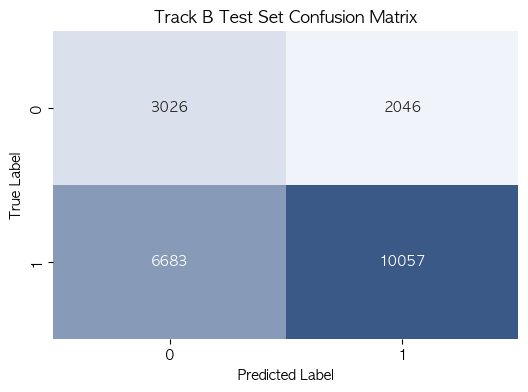

In [37]:
# Test set 평가 (Track A와 동일하게 valid에서 찾은 threshold를 test에 그대로 적용)
test_proba_b = trackb_pipeline.predict_proba(X_test_b)[:, 1]
test_pred_b = (test_proba_b >= best_threshold_b).astype(int)

print("="*60)
print("TRACK B (사전 예측) TEST SET EVALUATION")
print("="*60)
print(f"TEST ACC: {accuracy_score(y_test, test_pred_b):.4f}")
print(f"TEST Balanced ACC: {balanced_accuracy_score(y_test, test_pred_b):.4f}")
print(f"TEST Negative Recall (Class 0): {recall_score(y_test, test_pred_b, pos_label=0):.4f}")
print(f"TEST F1 (macro): {f1_score(y_test, test_pred_b, average='macro'):.4f}")
print(f"TEST F1 (weighted): {f1_score(y_test, test_pred_b, average='weighted'):.4f}")

print("\n[Classification Report]")
print(classification_report(y_test, test_pred_b, zero_division=0))

print("[Confusion Matrix]")
print(confusion_matrix(y_test, test_pred_b))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, test_pred_b), annot=True, fmt='d', cmap=blue_cmap, cbar=False)
plt.title('Track B Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [38]:
# Track A vs Track B vs Baseline 비교 (하드코딩 없이 각 셀에서 계산된 실제 변수를 그대로 사용)
final_comparison = pd.DataFrame([
    {
        "track": "Track A (LightGBM, 사후 원인분석)",
        "n_features": X_train.shape[1],
        "accuracy": accuracy_score(y_test, test_pred),
        "balanced_acc": balanced_accuracy_score(y_test, test_pred),
        "neg_recall": recall_score(y_test, test_pred, pos_label=0),
        "macro_f1": f1_score(y_test, test_pred, average='macro'),
    },
    {
        "track": "Track B (LightGBM, 사전 예측)",
        "n_features": X_train_b.shape[1],
        "accuracy": accuracy_score(y_test, test_pred_b),
        "balanced_acc": balanced_accuracy_score(y_test, test_pred_b),
        "neg_recall": recall_score(y_test, test_pred_b, pos_label=0),
        "macro_f1": f1_score(y_test, test_pred_b, average='macro'),
    },
    {
        "track": "Baseline (다수 클래스)",
        "n_features": 0,
        "accuracy": accuracy_score(y_test, baseline_pred),
        "balanced_acc": balanced_accuracy_score(y_test, baseline_pred),
        "neg_recall": recall_score(y_test, baseline_pred, pos_label=0, zero_division=0),
        "macro_f1": f1_score(y_test, baseline_pred, average='macro'),
    },
])
final_comparison.to_csv(TABLE_DIR / 'track_a_vs_b_comparison.csv', index=False)
final_comparison


,track,n_features,accuracy,balanced_acc,neg_recall,macro_f1
0,"Track A (LightGBM, 사후 원인분석)",33,0.652210,0.650698,0.647871,0.603370
1,"Track B (LightGBM, 사전 예측)",22,0.599807,0.598693,0.596609,0.553403
2,Baseline (다수 클래스),0,0.767467,0.500000,0.000000,0.434219


## Track A vs Track B 해석

*(order_id 기준 `GroupShuffleSplit`으로 train/valid/test를 분리하고, 탐색 단계는 `StratifiedGroupKFold`로 order_id 단위 누수를 막은 뒤의 test set 결과입니다.)*

| | Track A (사후) | Track B (사전) | Baseline |
|---|---|---|---|
| accuracy | 0.653 | 0.600 | 0.767 |
| balanced_acc | 0.651 | 0.599 | 0.500 |
| neg_recall | 0.647 | 0.597 | 0.000 |
| macro_f1 | 0.604 | 0.553 | 0.434 |

- **accuracy만 보면 baseline(0.767)이 가장 높지만 착시입니다.** 데이터가 긍정 77% : 부정 23%로 불균형해서, 아무 판단 없이 전부 "긍정"이라고만 찍어도 accuracy가 높게 나옵니다. balanced_acc는 0.5(동전 던지기 수준), neg_recall은 0(부정 리뷰를 단 하나도 못 잡음)이라는 게 이 모델이 실무적으로 무가치하다는 증거입니다.
- **Track B는 accuracy가 baseline보다 낮지만(0.600 < 0.767), balanced_acc·neg_recall·macro_f1은 모두 baseline을 크게 앞섭니다.** 즉 배송 전 정보만으로도 부정 리뷰 위험의 약 60%를 사전에 잡아낼 수 있다는 뜻이며, 이게 실무 가치입니다.
- **Track A가 Track B보다 모든 핵심 지표에서 우수한 것은 예상된 결과입니다.** 배송 결과(지연 여부 등)라는 강한 신호를 쓸 수 있는지 여부의 차이이며, 두 트랙의 성능 차이(neg_recall 0.647 vs 0.597) 자체가 사전 예측은 사후 설명보다 본질적으로 어렵다는 정량적 근거입니다.
- 결론: 실무에서는 두 모델을 함께 씁니다. **Track B로 주문 확정 시점에 고위험군을 선별해 우선 처리**하고, 그래도 놓친 건 **Track A로 배송 완료 후 CS 우선순위**를 매기는 2단계 대응 체계가 됩니다.
